In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1'

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

2025-01-16 15:05:16.624879: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1737036316.649664  623051 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1737036316.659265  623051 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train_full = X_train_full.astype(np.float32) / 255
X_test = X_test.astype(np.float32) / 255
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

In [3]:
def plot_multiple_images(images, n_cols=None):
    n_cols = n_cols or len(images)
    n_rows = (len(images) - 1) // n_cols + 1
    if images.shape[-1] == 1:
        images = images.squeeze(axis=-1)
    plt.figure(figsize=(n_cols, n_rows))
    for index, image in enumerate(images):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(image, cmap="binary")
        plt.axis("off")

In [4]:
codings_size = 30

generator = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(150, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(28 * 28, activation="sigmoid"),
    tf.keras.layers.Reshape([28, 28])
], name="generator")
discriminator = tf.keras.Sequential([
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(150, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(1, activation="sigmoid")
], name="discriminator")

In [5]:
class GAN(tf.keras.Model):
    def __init__(self, discriminator, generator, codings_size):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.codings_size = codings_size

    def compile(self, discriminator_optimizer, generator_optimizer, loss_function):
        super().compile()
        self.discriminator_optimizer = discriminator_optimizer
        self.generator_optimizer = generator_optimizer
        self.loss_function = loss_function
        self.discriminator_loss_metric = tf.keras.metrics.Mean(name='d_loss')
        self.generator_loss_metric = tf.keras.metrics.Mean(name='g_loss')

    @property
    def metrics(self):
        return [self.discriminator_loss_metric, self.generator_loss_metric]
    
    def train_step(self, real_images):
        batch_size = tf.keras.ops.shape(real_images)[0]
        noise = tf.random.normal(shape=[batch_size, self.codings_size])
        generated_images = generator(noise)
        X_fake_and_real = tf.concat([generated_images, real_images], axis=0)
        labels = tf.constant([[0.]] * batch_size + [[1.]] * batch_size)
        with tf.GradientTape() as tape:
            predictions = self.discriminator(X_fake_and_real)
            discriminator_loss = self.loss_function(labels, predictions)
        grads = tape.gradient(discriminator_loss, self.discriminator.trainable_weights)
        self.discriminator_optimizer.apply_gradients(
            zip(grads, self.discriminator.trainable_weights)
        )

        noise = tf.random.normal(shape=[batch_size, self.codings_size])
        generated_images = generator(noise)
        labels = tf.constant([[1.]] * batch_size)
        with tf.GradientTape() as tape:
            predictions = self.discriminator(self.generator(noise))
            generator_loss = self.loss_function(labels, predictions)
        grads = tape.gradient(generator_loss, self.generator.trainable_weights)
        self.generator_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

        self.discriminator_loss_metric.update_state(discriminator_loss)
        self.generator_loss_metric.update_state(generator_loss)

        return {
            "d_loss": self.discriminator_loss_metric.result(),
            "g_loss": self.generator_loss_metric.result(),
        }

In [6]:
batch_size = 32
dataset = tf.data.Dataset.from_tensor_slices(X_train).shuffle(1000)
dataset = dataset.batch(batch_size, drop_remainder=True).prefetch(1)

I0000 00:00:1737036322.660396  623051 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9711 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


In [7]:
epochs = 60

gan = GAN(discriminator=discriminator, generator=generator, codings_size=codings_size)
gan.compile(
    discriminator_optimizer=tf.keras.optimizers.RMSprop(),
    generator_optimizer=tf.keras.optimizers.RMSprop(),
    loss_function=tf.keras.losses.BinaryCrossentropy(),
)

In [8]:
gan.fit(
    dataset, epochs=epochs
)

Epoch 1/60


I0000 00:00:1737036326.213347  623140 service.cc:148] XLA service 0x7f793c00b940 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1737036326.213427  623140 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
I0000 00:00:1737036326.702766  623140 cuda_dnn.cc:529] Loaded cuDNN version 90300


  20/1718 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - d_loss: 0.6815 - g_loss: 2.0985  

I0000 00:00:1737036344.324938  623140 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1718/1718 ━━━━━━━━━━━━━━━━━━━━ 35s 8ms/step - d_loss: 0.4957 - g_loss: 1.6304
Epoch 2/60
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - d_loss: 0.5161 - g_loss: 1.4208
Epoch 3/60
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - d_loss: 0.4780 - g_loss: 1.6098
Epoch 4/60
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - d_loss: 0.4739 - g_loss: 1.7039
Epoch 5/60
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - d_loss: 0.4568 - g_loss: 1.9947
Epoch 6/60
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - d_loss: 0.4519 - g_loss: 1.9363
Epoch 7/60
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - d_loss: 0.4435 - g_loss: 1.8238
Epoch 8/60
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - d_loss: 0.4499 - g_loss: 1.5942
Epoch 9/60
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - d_loss: 0.4770 - g_loss: 1.4184
Epoch 10/60
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - d_loss: 0.4991 - g_loss: 1.2950
Epoch 11/60
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - d_loss: 0.5150 - g_loss: 1.1776
Epoch 12/60
1718/1718 ━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


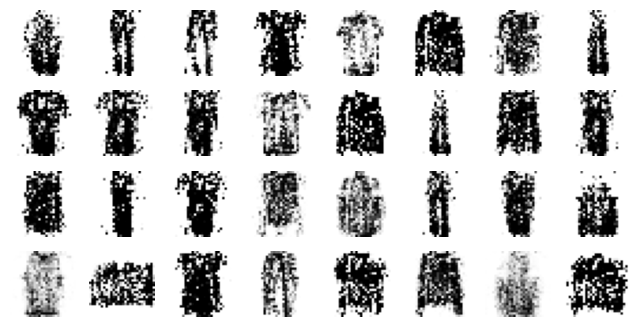

In [9]:
codings = tf.random.normal(shape=[batch_size, codings_size])
generated_images = generator.predict(codings)
plot_multiple_images(generated_images, 8)
plt.show()